# **Implementación del caso de 10 Qubits.**

In [2]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

In [3]:
N10 = 261980999226229

## **Implementación con 8 Qubits**

In [4]:
seed = 51

In [5]:
eightQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [6]:
B8, t8 = eightQubit.generate_cvp(10)
print(f'B8 = \n{B8}')
print(f't8 = \n{t8}')

B8 = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t8 = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [7]:
D8, b8_op, res8_vector, sign_step8, w8, dist8 = eightQubit.babai_algorithm(B8, t8, delta = 0.75)
print(f'D8 = \n{D8}\n')
print(f'b8_op = \n{b8_op}\n')
print(f'res8_vector = \n{res8_vector}\n')
print(f'sign_step8 = \n{sign_step8}\n')
print(f'w8 = \n{w8}\n')
print(f'dist8 = \n{dist8}\n')

D8 = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b8_op = 
[     2      0      2      0      0      3     10      0 331994]

res8_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

sign_step8 = 
[ 1 -1 -1 -1  1  1  1 -1]

w8 = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)

dist8 = 
10.862780491200215



In [8]:
qubo8 = eightQubit.define_qubo(D8, res8_vector, sign_step8)
print(qubo8.prettyprint())

Hc8, offset8 = eightQubit.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [9]:
circuit8 = eightQubit.construct_circuit(Hc8, reps = 1)
print(circuit8.decompose())

     ┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     ├───┤»
q_6: ┤ H ├»
     ├───┤»
q_7: ┤ H ├»
     └───┘»
«     ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                             

In [10]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
optParameters8 = eightQubit.qaoa_algorithm(circuit8, Hc8, x0)

In [11]:
for param in optParameters8.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.4799726604811829
γ[0] = 0.008447652215877989


In [12]:
results8 = eightQubit.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

215
Bistring: 00010011 -> Counts: 365
Bistring: 00000100 -> Counts: 362
Bistring: 00100110 -> Counts: 310
Bistring: 00000000 -> Counts: 299
Bistring: 00010010 -> Counts: 273
Bistring: 00000010 -> Counts: 260
Bistring: 00000101 -> Counts: 242
Bistring: 01010110 -> Counts: 241
Bistring: 00001010 -> Counts: 235
Bistring: 00010111 -> Counts: 222
Bistring: 10000100 -> Counts: 219
Bistring: 10010100 -> Counts: 204
Bistring: 00100100 -> Counts: 202
Bistring: 00100010 -> Counts: 193
Bistring: 00000110 -> Counts: 193
Bistring: 10010010 -> Counts: 192
Bistring: 00010101 -> Counts: 191
Bistring: 10010110 -> Counts: 185
Bistring: 11010110 -> Counts: 172
Bistring: 01010111 -> Counts: 168
Bistring: 00100111 -> Counts: 165
Bistring: 01000110 -> Counts: 161
Bistring: 01000100 -> Counts: 160
Bistring: 01010010 -> Counts: 156
Bistring: 00010110 -> Counts: 136
Bistring: 00000001 -> Counts: 133
Bistring: 00001000 -> Counts: 130
Bistring: 00011011 -> Counts: 128
Bistring: 00011010 -> Counts: 128
Bistring: 

In [13]:
nD8 = eightQubit.integer_to_matrix(D8)
vnew8 = eightQubit.bitstring2latticeVectors(nD8, results8.keys(), sign_step8, b8_op)
for vect8 in vnew8:
    print(vect8)

[     0      3      0      0      4      3      6      4 331987]
[    -4      3      2      0      4      3      8     -4 331995]
[    -2      0      4      0      8     -3      6     -4 331988]
[     2      0      2      0      0      3     10      0 331994]
[    -2      3      4      4      1      3      8      0 331986]
[     2      3     -2      0      2      0     11     -4 331989]
[    -2      3     -2     -4      7      3      6      0 331996]
[    -6      0      0      8      6      0      6      0 331991]
[    -2      3      0      0      4     -6     10      0 331993]
[    -6      6      0      0      8      3      4      0 331988]
[     4      6      2      0      7      0      5     -4 331997]
[     0      6      8      4      6      3      2      0 331994]
[    -2     -3      8      0      6      0      5      0 331993]
[     4     -3      4      0      4     -3      8      0 331987]
[    -4      6     -2      0      6      0      9     -8 331990]
[     6      6      4    

In [14]:
distances8 = eightQubit.get_distances(vnew8, t8)
for dist in distances8:
    print(dist)

11.045361017187261
11.74734012447073
13.038404810405298
10.862780491200215
12.96148139681572
13.19090595827292
11.661903789690601
13.2664991614216
12.84523257866513
13.638181696985855
12.727922061357855
12.884098726725126
11.74734012447073
12.884098726725126
15.684387141358123
13.038404810405298
12.569805089976535
14.7648230602334
13.2664991614216
12.727922061357855
13.341664064126334
14.560219778561036
12.569805089976535
12.884098726725126
15.937377450509228
11.74734012447073
12.449899597988733
12.922847983320086
13.74772708486752
12.165525060596439
12.884098726725126
12.083045973594572
13.856406460551018
13.038404810405298
14.696938456699069
15.556349186104045
14.966629547095765
14.352700094407323
14.035668847618199
14.142135623730951
13.416407864998739
14.071247279470288
14.696938456699069
14.0
15.874507866387544
13.784048752090222
14.798648586948742
14.7648230602334
13.784048752090222
16.76305461424021
13.341664064126334
14.38749456993816
13.19090595827292
13.711309200802088
16.552

In [15]:
nB8 = eightQubit.integer_to_matrix(B8)
uv_pairs8 = eightQubit.vectors2uv_pairs(nB8, vnew8)
print(uv_pairs8)

[[261868027467189 1]
 [19915752615267795 76]
 [129352557022507225 494]
 [262079207058370 1]
 [523704989883075 2]
 [24881396719341558 95]
 [18344544450464661 70]
 [2095297617885241 8]
 [88548500089421427 338]
 [2094705767700117 8]
 [4980419307818460 19]
 [262070340406875 1]
 [1572102054235625 6]
 [10213206469368100 39]
 [1890770913674116353 7220]
 [261930391846200 1]
 [2096063541654225 8]
 [4976110986617925 19]
 [3405871519729602 13]
 [26192773830301463 100]
 [23829516041101331 91]
 [16176595594767439909 61750]
 [7864168981413437 30]
 [785826051486091 3]
 [79594097822264025 304]
 [9173316356123348 35]
 [6815838201665075 26]
 [13620692197897455 52]
 [27239768591429625 104]
 [5502683577794425 21]
 [262085885854650 1]
 [262037768531825 1]
 [229184353172620164 875]
 [262100173335000 1]
 [261916113620898 1]
 [8708014138755186387 33250]
 [4191878430114375 16]
 [398405875629322253 1521]
 [44277791974589250 169]
 [6289967326417775 24]
 [262157171406240 1]
 [3407234413495000 13]
 [12772450315928

In [16]:
sr_pairs8 = eightQubit.uv_pairs2sr_pairs(uv_pairs8)
print(sr_pairs8)

[]


In [17]:
probs8 = eightQubit.get_probs(results8.values(), shots = 10_000)

In [18]:
eightQubit.prettyprint(vnew8, distances8, probs8, b8_op, t8, res8_vector, dist8)

Vector más corto por algoritmo de Babai: 
b_op = [     2      0      2      0      0      3     10      0 331994]

El vector residual 
t - b_op = [ -2   0  -2   0   0  -3 -10   0  -1]

La distancia |t - b_op| = 10.863

0: Prob = 0.03650
	vnew = [     0      3      0      0      4      3      6      4 331987] con distancia: 11.045
1: Prob = 0.03620
	vnew = [    -4      3      2      0      4      3      8     -4 331995] con distancia: 11.747
2: Prob = 0.03100
	vnew = [    -2      0      4      0      8     -3      6     -4 331988] con distancia: 13.038
3: Prob = 0.02990
	vnew = [     2      0      2      0      0      3     10      0 331994] con distancia: 10.863
4: Prob = 0.02730
	vnew = [    -2      3      4      4      1      3      8      0 331986] con distancia: 12.961
5: Prob = 0.02600
	vnew = [     2      3     -2      0      2      0     11     -4 331989] con distancia: 13.191
6: Prob = 0.02420
	vnew = [    -2      3     -2     -4      7      3      6      0 331996] con distanci

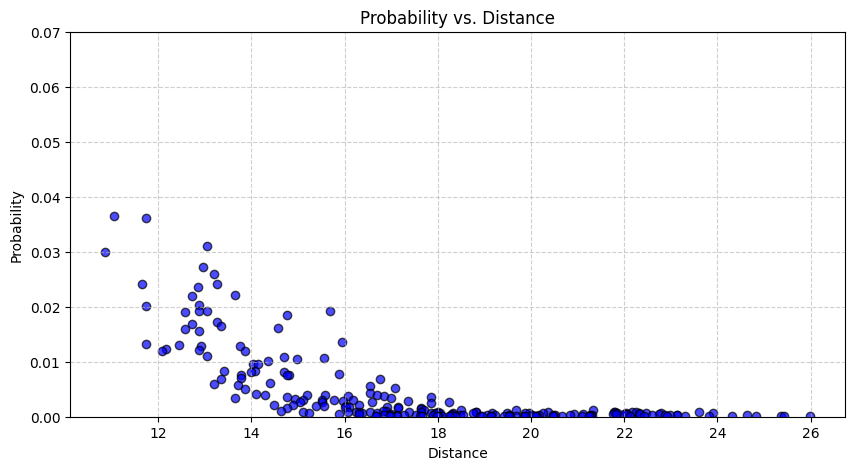

In [19]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.07) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Implementación con 10 Qubits**

In [20]:
seed = 42

In [21]:
tenQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [22]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [23]:
B10, t10 = tenQubit.generate_cvp(10)
print(f'B10 = \n{B10}')
print(f't10 = \n{t10}')

B10 = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t10 = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [24]:
D10, b10_op, res10_vector, sign_step10, w10, dist10 = tenQubit.babai_algorithm(B10, t10, delta = 0.75)
print(f'D10 = \n{D10}\n')
print(f'b10_op = \n{b10_op}\n')
print(f'res10_vector = \n{res10_vector}\n')
print(f'sign_step10 = \n{sign_step10}\n')
print(f'w10 = \n{w10}\n')
print(f'dist10 = \n{dist10}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b10_op = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res10_vector = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

sign_step10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

w10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)

dist10 = 
11.357816691600547



In [25]:
qubo10 = tenQubit.define_qubo(D10, res10_vector, sign_step10)
print(qubo10.prettyprint())
Hc10, offset10 = tenQubit.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [26]:
circuit10 = tenQubit.construct_circuit(Hc10, reps= 1)
print(circuit10.decompose(reps = 2))

     ┌────────────┐ ┌────────────────┐                              »
q_0: ┤ U(π/2,0,π) ├─┤ Rz((-90)*γ[0]) ├─■─────────────■──────────────»
     ├────────────┤┌┴────────────────┤ │ZZ(20*γ[0])  │              »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-107)*γ[0]) ├─■─────────────┼──────────────»
     ├────────────┤└┬────────────────┤               │ZZ((-6)*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz((-66)*γ[0]) ├───────────────■──────────────»
     ├────────────┤ └┬──────────────┬┘                              »
q_3: ┤ U(π/2,0,π) ├──┤ Rz(115*γ[0]) ├───────────────────────────────»
     ├────────────┤┌─┴──────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-111)*γ[0]) ├──────────────────────────────»
     ├────────────┤└┬────────────────┤                              »
q_5: ┤ U(π/2,0,π) ├─┤ Rz((-54)*γ[0]) ├──────────────────────────────»
     ├────────────┤ └┬─────────────┬─┘                              »
q_6: ┤ U(π/2,0,π) ├──┤ Rz(16*γ[0]) ├────────────────────────────────»
     ├────────────┤┌

In [27]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
optParameters10 = tenQubit.qaoa_algorithm(circuit10, Hc10, x0)

In [28]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = 0.5090447457358702
γ[0] = -0.008621815614845957


In [29]:
results10 = tenQubit.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

574
Bistring: 1001001000 -> Counts: 229
Bistring: 0000001000 -> Counts: 227
Bistring: 0000000000 -> Counts: 219
Bistring: 0001001000 -> Counts: 209
Bistring: 1001101000 -> Counts: 192
Bistring: 0001011000 -> Counts: 188
Bistring: 0001101100 -> Counts: 177
Bistring: 0001101000 -> Counts: 156
Bistring: 1001001001 -> Counts: 155
Bistring: 1001011000 -> Counts: 141
Bistring: 0000001010 -> Counts: 137
Bistring: 0000101100 -> Counts: 131
Bistring: 0001001001 -> Counts: 130
Bistring: 0000001100 -> Counts: 128
Bistring: 1000001000 -> Counts: 123
Bistring: 1000001010 -> Counts: 120
Bistring: 1011001000 -> Counts: 116
Bistring: 0101001000 -> Counts: 111
Bistring: 0000001001 -> Counts: 104
Bistring: 0001000000 -> Counts: 103
Bistring: 0000001101 -> Counts: 103
Bistring: 1001101010 -> Counts: 101
Bistring: 1000000000 -> Counts: 92
Bistring: 0011001000 -> Counts: 90
Bistring: 0001100000 -> Counts: 90
Bistring: 0001011100 -> Counts: 88
Bistring: 1001000000 -> Counts: 88
Bistring: 1001101100 -> Count

In [30]:
nD10 = tenQubit.integer_to_matrix(D10)
vnew10 = tenQubit.bitstring2latticeVectors(nD10, results10.keys(), sign_step10, b10_op)
for vect10 in vnew10:
    print(vect10)

[     0      1      0      4      4      0      5      3      6      8
 331988]
[     0     -3      3      7      0      0      5      6      8      0
 331989]
[     0      1      0      6      0      4      0      6      6      0
 331991]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     0      2      6      4      4      4      5      0      4      4
 331988]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     5      4      3      4     -4      2      5      3      6      4
 331989]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[     0      0      3      7      4      2      0      0      4      8
 331991]
[     5      0      0      9      0      0      5      6      4      0
 331992]
[     0      2      6      8     -4      2      5      3      4      0
 331988]
[     5      0      3      2      0     

In [31]:
distances10 = tenQubit.get_distances(vnew10, t10)
for dist in distances10:
    print(dist)

13.856406460551018
14.422205101855956
11.357816691600547
14.866068747318506
13.038404810405298
12.922847983320086
13.711309200802088
13.892443989449804
13.114877048604
12.727922061357855
13.564659966250536
14.106735979665885
14.177446878757825
14.933184523068078
14.730919862656235
13.379088160259652
13.379088160259652
14.594519519326424
14.212670403551895
13.416407864998739
14.317821063276353
13.114877048604
12.649110640673518
15.165750888103101
12.806248474865697
14.2828568570857
13.152946437965905
14.247806848775006
13.820274961085254
12.922847983320086
14.212670403551895
13.564659966250536
14.071247279470288
12.649110640673518
13.416407864998739
16.852299546352718
14.247806848775006
12.96148139681572
14.422205101855956
13.601470508735444
14.352700094407323
14.560219778561036
12.767145334803704
14.52583904633395
14.422205101855956
15.652475842498529
13.601470508735444
14.966629547095765
14.628738838327793
14.730919862656235
13.379088160259652
13.674794331177344
15.874507866387544
14.

In [32]:
nB10 = tenQubit.integer_to_matrix(B10)
uv_pairs10 = tenQubit.vectors2uv_pairs(nB10, vnew10)
for pair10 in uv_pairs10:
    print(pair10)

[261871433827773 1]
[7071698751104155 27]
[261991323844341 1]
[785809757098954 3]
[261912761285175 1]
[2358275479138670 9]
[2881406685691170 11]
[261977923439050 1]
[262012871275155 1]
[261965433534805 1]
[262013791156222 1]
[2881166688465975 11]
[262078058335730 1]
[37449256864542873 143]
[1571097732684865 6]
[261948620080917 1]
[44273270057020389 169]
[262077260557707 1]
[2358506064707975 9]
[1310065736807646 5]
[2882267946636435 11]
[262011783123090 1]
[523852316714727 2]
[44284284952292574 169]
[262054497183570 1]
[2881986154104582 11]
[1309739882231781 5]
[261880908106545 1]
[2881746108614485 11]
[262013355501975 1]
[21222711489550025 81]
[2882440977138450 11]
[524110863400845 2]
[262154507478003 1]
[14407770361112037 55]
[187261881680842038 715]
[262118620497825 1]
[2882008827066915 11]
[2882962940989950 11]
[262171334146995 1]
[2882954165114205 11]
[7600277737807650 29]
[261989315983395 1]
[523982095561925 2]
[1309852200204702 5]
[1284137296744619205 4901]
[7598947436446275 29]


In [33]:
sr_pairs10 = tenQubit.uv_pairs2sr_pairs(uv_pairs10)
print(sr_pairs10)

[]


In [34]:
probs10 = tenQubit.get_probs(results10.values(), shots = 10_000)

In [36]:
tenQubit.prettyprint(vnew10, distances10, probs10, b10_op, t10, res10_vector, dist10)

Vector más corto por algoritmo de Babai: 
b_op = [     0      1      0      6      0      4      0      6      6      0
 331991]

El vector residual 
t - b_op = [ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

La distancia |t - b_op| = 11.358

0: Prob = 0.02290
	vnew = [     0      1      0      4      4      0      5      3      6      8
 331988] con distancia: 13.856
1: Prob = 0.02270
	vnew = [     0     -3      3      7      0      0      5      6      8      0
 331989] con distancia: 14.422
2: Prob = 0.02190
	vnew = [     0      1      0      6      0      4      0      6      6      0
 331991] con distancia: 11.358
3: Prob = 0.02090
	vnew = [     5     -1      0      3      0      0      5      6     10      4
 331990] con distancia: 14.866
4: Prob = 0.01920
	vnew = [     0      2      6      4      4      4      5      0      4      4
 331988] con distancia: 13.038
5: Prob = 0.01880
	vnew = [     5     -2      3      6      0      2      0      3      8      4
 331993] con distancia: 12.923
6

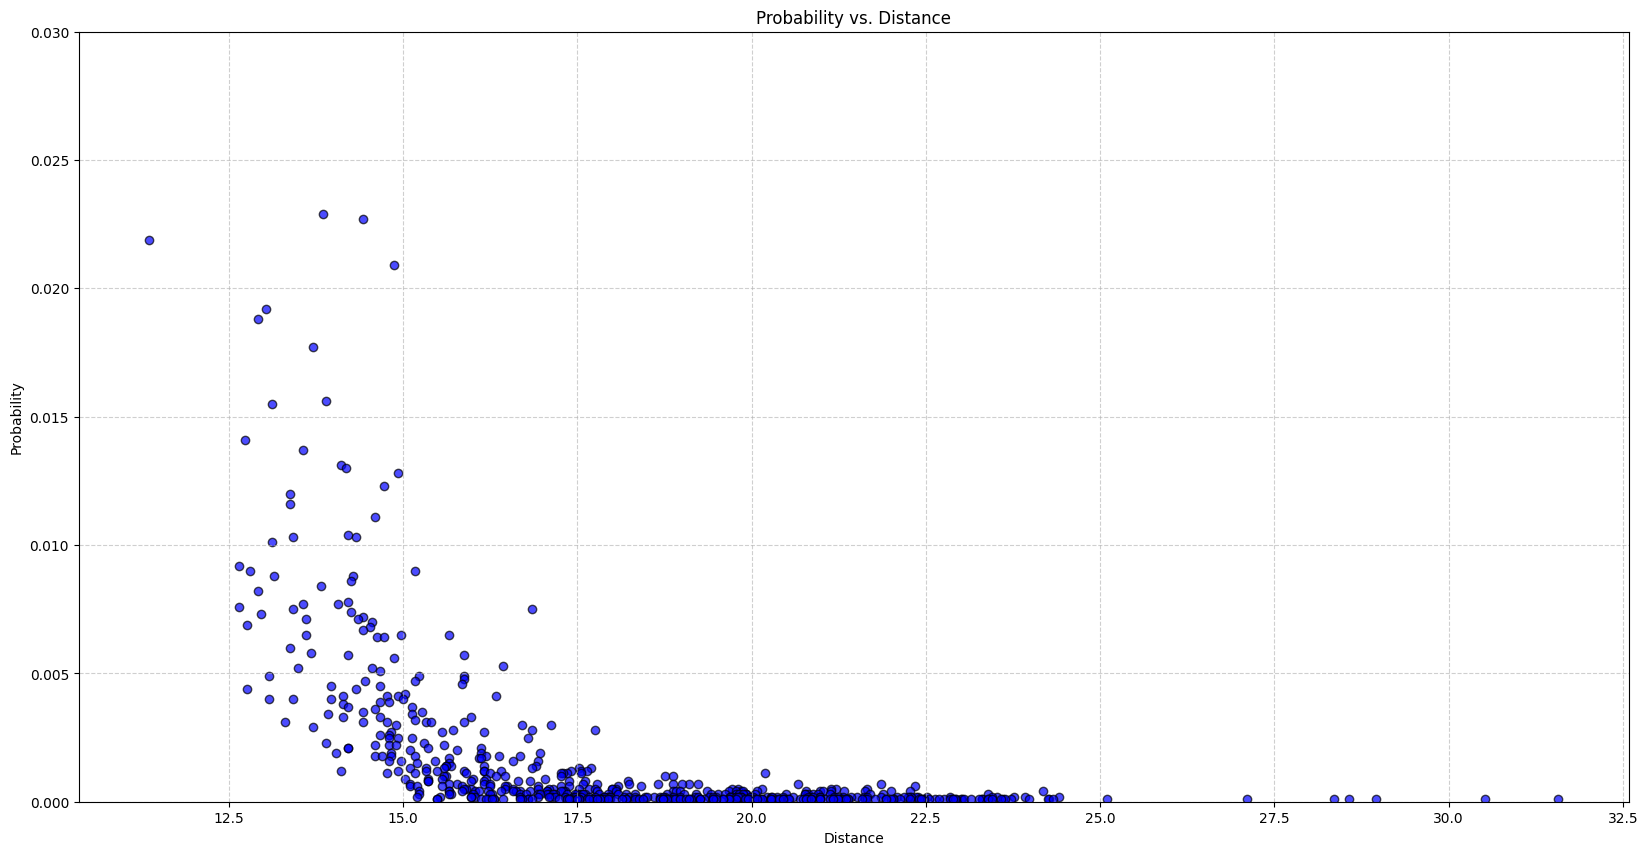

In [35]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()